In [1]:
import json
from Bio import SeqIO
from augur.utils import json_to_tree
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## count the number of human influenza HA fixations

Compare this to the number of different egg-adaptive mutations observed

In [2]:
def readin_mut_freqs(virus):
    """
    Readin the mut frequencies, which were generated from AA alignment with:
    
    augur frequencies --metadata alltime-ha1-alignments/yam_metadata.tsv 
    --alignments alltime-ha1-alignments/yam_HA1_withInternalNodes.fasta 
    --gene-names HA1 --method kde --output yam_ha1_mut_frequencies.json
    
    This will be every mutation observed on the tree and the frequency it is present at, at each pivot
    """
    
    freqs_file = f'../nextstrain_builds/human-influenza-freqs/{virus}_ha1_mut_frequencies.json'
    
    with open(freqs_file) as json_handle:
        freqs_json = json.load(json_handle)
        
    return freqs_json

In [3]:
def get_fixations(virus, start_date=None):
    """
    For every AA mutation, find the max frequency it reaches over time
    Keep track of how many fix (allow >95% as fixing)
    """
    
    freqs_input = readin_mut_freqs(virus)
    # limit frequency data to just that after the start date
    if start_date !=None:
        start_pivot = next((i for i, v in enumerate(freqs_input['pivots']) if v >= start_date), None)
        freqs = {k:v[start_pivot:] for k,v in freqs_input.items() if k not in ['pivots','generated_by']}
        pivots = freqs_input['pivots'][start_pivot:]
        
    else:
        freqs= {k:v for k,v in freqs_input.items() if k not in ['pivots','generated_by']}
        pivots = freqs_input['pivots']
    
    
    # count the number of fixations in HA1 throughout the tree
    fixations = []
    
    for k,f in freqs.items():
        mut = k[4:]
        max_freq = max(f)

        # see if this mutation fixes
        if max_freq >= 0.95:
            # if mut is already fixed at the beginning, then we won't consider it a fixation
            # unless something else fixes, and then this mut RE-fixes
            # in that case, we need the freq to drop below 10% and then reach ~100% again
            if f[0]>0.95:
                unfixation_index = next((i for i, v in enumerate(f) if v < 0.1), None)
                if unfixation_index is not None:

                    refixation = any(v > 0.95 for v in f[unfixation_index+1:])
                    if refixation:
                        fixations.append(mut)

            else:
                fixations.append(mut)
                
                
    sorted_fixations = sorted(fixations, key=lambda x: int(''.join([ch for ch in x if ch.isdigit()])))
    num_fixations = len(sorted_fixations)
    
    time_duration = pivots[-1] - pivots[0]
    
    return num_fixations, time_duration

In [4]:
# number of adaptive mutations (from Figure 3)
num_egg_adaptive_mut_aas = {'h3n2': 27, 'h1n1pdm': 8, 'vic': 8, 'yam': 8}

num_egg_adaptive_mut_sites = {'h3n2': 15, 'h1n1pdm': 5, 'vic': 3, 'yam': 3}

In [5]:
cmap = {'Yam': '#fbba0a', 
        'Vic' : '#FF4500',
        'H3N2': '#6C3BAA',
        'H1N1pdm': '#45b6fe'}

In [7]:
legible_names = {'h3n2': 'H3N2', 'h1n1pdm': 'H1N1pdm', 'vic': 'Vic', 'yam': 'Yam'}

In [8]:
def make_supp_fig(aa_or_site = 'site', filename=None):
    """
    plot number of HA1 fixations per year
    against number of egg-adaptive muts (per year)
    
    option to plot number of egg muts by site or by unique AA
    """
    
    to_plot = []
    
    for virus in ['h3n2', 'h1n1pdm', 'vic', 'yam']:
        num_fixations, time = get_fixations(virus, start_date = 1995)
        num_fixations_per_year = num_fixations/time
        
        if aa_or_site == 'site':
            num_egg_muts = num_egg_adaptive_mut_sites[virus]
        elif aa_or_site == 'aa':
            num_egg_muts = num_egg_adaptive_mut_aas[virus]
            
        num_egg_muts_per_year = num_egg_muts/time
        
        to_plot.append({'virus': legible_names[virus], 'num_fixations_per_year':num_fixations_per_year, 
                        'num_egg_muts_per_year': num_egg_muts_per_year})
        
    df = pd.DataFrame(to_plot)
    
    #plot styling
    sns.set_style("white")
    plt.rcParams['figure.dpi']= 300
    plt.rcParams['font.family'] = 'Arial'
    
    fig, ax = plt.subplots()
    
    ax = sns.scatterplot(x='num_fixations_per_year', y = 'num_egg_muts_per_year', 
                         hue= 'virus', palette= cmap, data=df, s=100)
    
    ax.set_xlabel('Number of fixations per year, human influenza')
    ax.set_ylabel('Number of egg adaptive mutations per year')
    
    ax.legend().set_title(None)
    
    sns.despine()
    
    if filename:
        fig.savefig(filename, dpi=400, bbox_inches='tight', transparent=False, facecolor='white')

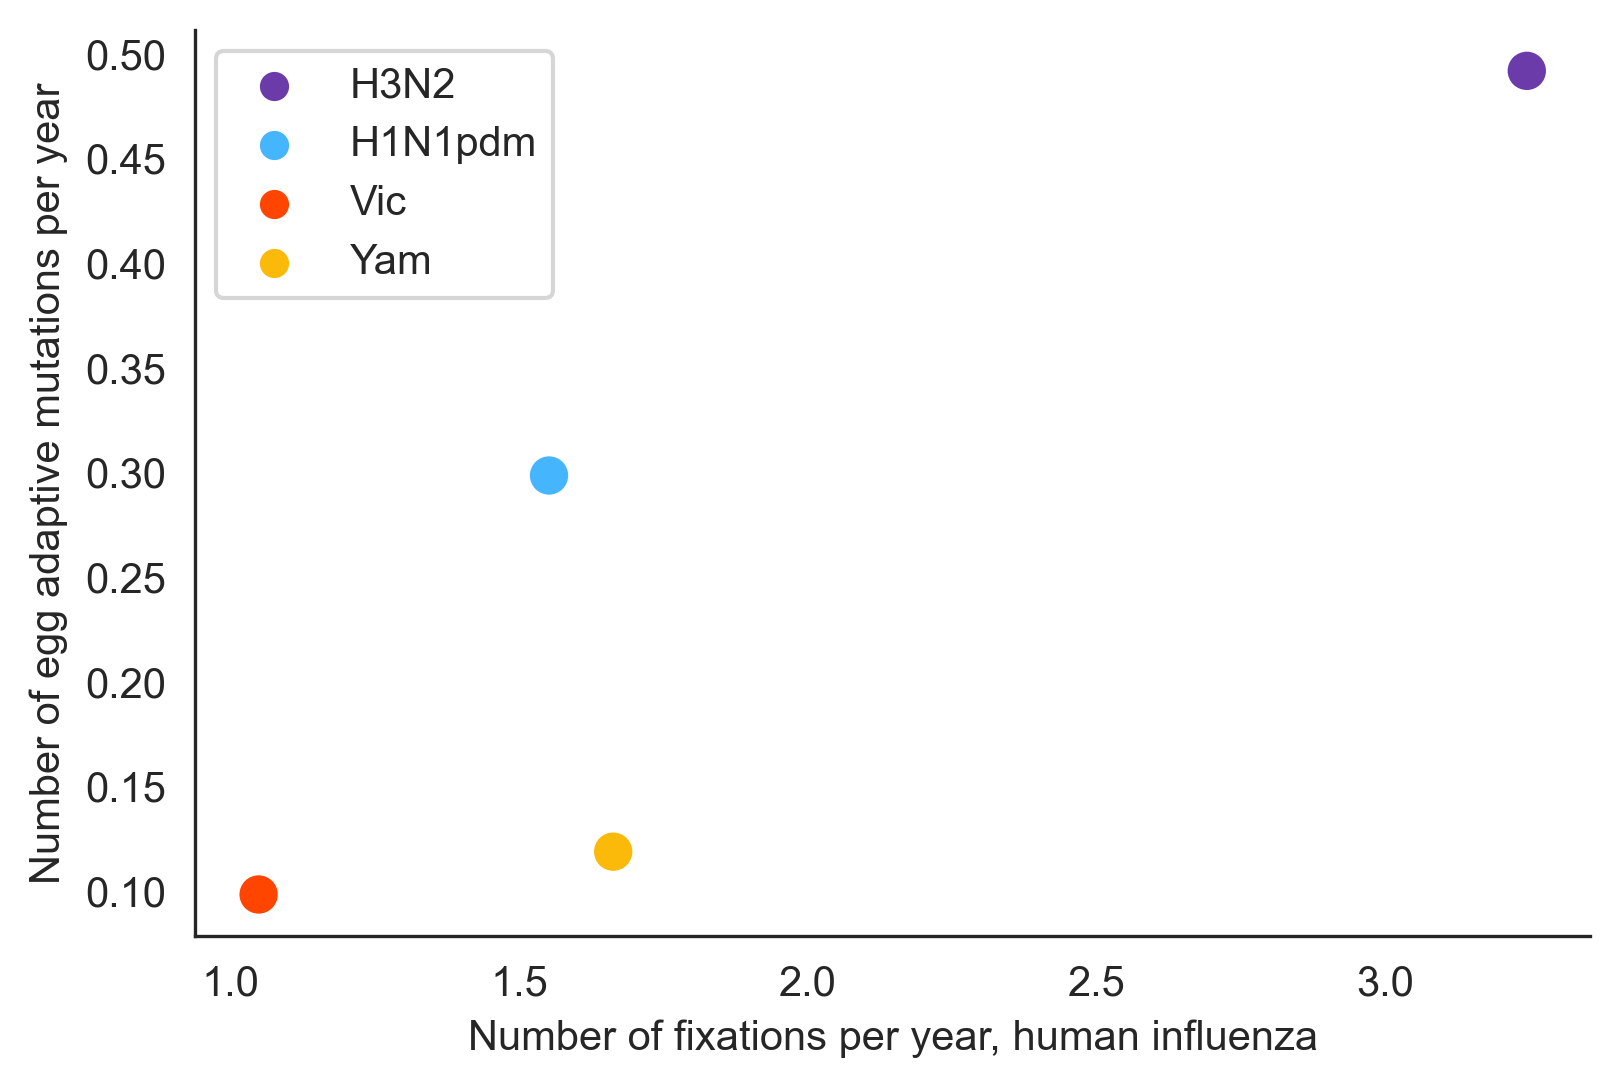

In [10]:
make_supp_fig('site', filename='Supplement-humanFixations/human_fixations_to_egg_muts.png')

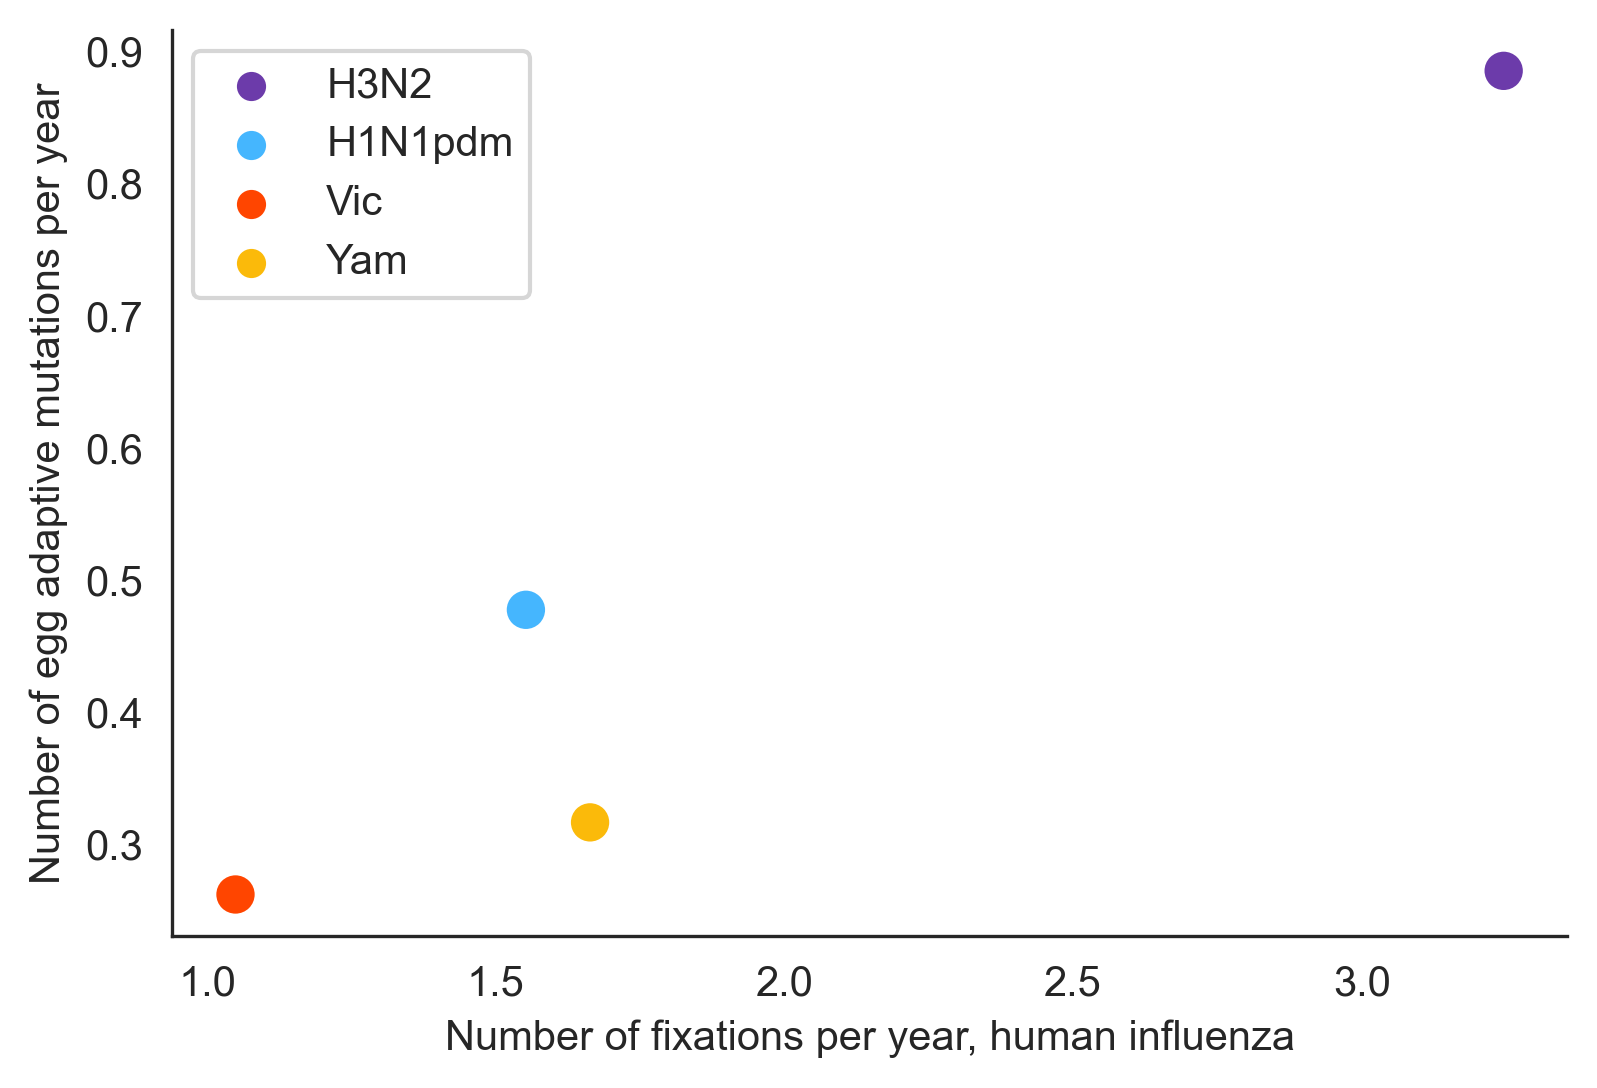

In [11]:
make_supp_fig('aa')